# Re-measured SDSSRM-XCS Relations: $L_{\rm{X}}$-$T_{\rm{X}}$

This section of the project fits scaling relations to the measurements of properties made in the first paper of this series [(Turner et al. 2024)](https://ui.adsabs.harvard.edu/abs/2025MNRAS.tmp...10T/abstract).

Here we focus on scaling relations between the X-ray luminosity of galaxy clusters and groups ($L_{\rm{X}}$, or $L^{0.5-2.0}_{\rm{X},\Delta}$ within an overdensity radius $R_{\Delta}$ and within 0.5-2.0 keV energy bounds), and cluster/group global X-ray temperature ($T_{\rm{X}}$, or $T_{\rm{X},\Delta}$ within $R_{\Delta}$). If present in a property name, 'ce' means 'core-excised', normally 0.15$R_{500}$. When we refer to the bolometric (with shorthand 'bol') we are talking about the entire energy range of the telescope.

**This set of scaling relations is different to the others created in this project, as they are re-measurements of a set of luminosity-temperature relations published by [Giles et al. 2022](https://ui.adsabs.harvard.edu/abs/2022MNRAS.516.3878G/abstract). We expect the re-measurements to be consistent with the original relations, as the luminosities and temperatures we measured in [Turner et al. 2024](https://ui.adsabs.harvard.edu/abs/2025MNRAS.tmp...10T/abstract) were consistent.**

Relation fits are performed using the XGA interface to the R scaling-relation fitting package LIRA, see the paper for full details.

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from astropy.units import Quantity
from astropy.cosmology import LambdaCDM

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '..')
from common import xcs_cosmo, tx_norm, lx_norm

import xga
from xga.relations.fit import scaling_relation_lira

## Normalisation values

These are used when fitting the scaling relations to normalise the data, and are kept the same throughout this entire project:

In [2]:
tx_norm

<Quantity 4. keV>

In [3]:
lx_norm

<Quantity 1.e+44 erg / s>

## Cosmological model

We use the same cosmology as was utilised in the initial paper of this series:

In [4]:
xcs_cosmo

LambdaCDM(name=None, H0=<Quantity 70. km / (Mpc s)>, Om0=0.3, Ode0=0.7, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0)

## Loading data files

Important considerations for this dataset:
* The X-ray cluster sample was originally assembled and analysed by [Giles et al. (2022)](https://ui.adsabs.harvard.edu/abs/2022MNRAS.516.3878G/abstract) - when we say 'SDSSRM-XCS' we are specifically referring to the volume limited ($0.1<z<0.35$) sample with fractional temperature errors of less than 25% - contains 150 clusters.
* SDSSRM-XCS is ultimately an *optically selected* sample however, as the original X-ray work (see above) found X-ray counterparts to clusters selected from the redMaPPer catalog of galaxy clusters produced from SDSS photometry [(Rykoff et al. 2014)](http://adsabs.harvard.edu/abs/2014ApJ...785..104R).
* These galaxy clusters were then further analysed in the first paper of this series [(Turner et al. 2024)](https://ui.adsabs.harvard.edu/abs/2025MNRAS.tmp...10T/abstract), measuring radial profiles of density and temperature that were used to calculate hydrostatic and gas masses - this work also re-measured luminosities and temperatures, which we will use in this section of the project.

### SDSSRM-XCS base sample

In [5]:
sdssxcs_base = pd.read_csv("../../sample_files/SDSSRM-XCS_base_sample.csv")
sdssxcs_base.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous
0,SDSSXCS-124,124,0.80058,-6.09182,0.798261,-6.091694,0.2475,1181.028,21.202,23.203,109.550,4.490,XMMXCS J000312.1-060530.5,1.018410,True,False
1,SDSSXCS-2789,2789,0.95554,2.06802,0.956981,2.066469,0.1053,1007.861,17.194,17.202,38.904,2.830,XMMXCS J000349.3+020404.8,0.827942,True,False
2,SDSSXCS-290,290,2.72264,29.16102,2.714137,29.161154,0.3485,913.052,30.879,31.210,105.096,5.994,XMMXCS J001053.4+290939.6,1.009990,True,False
3,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True
4,SDSSXCS-134,134,4.90839,3.60982,4.911069,3.599257,0.2773,1123.321,19.219,19.226,108.604,4.792,XMMXCS J001938.0+033635.3,1.016645,True,False
5,SDSSXCS-119,119,8.46470,-7.86290,8.471426,-7.869543,0.3042,944.275,46.422,46.747,128.192,5.697,XMMXCS J003351.5-075146.4,1.050926,True,False


Calculating E(z) values for these clusters:

In [6]:
sdssxcs_base['E'] = xcs_cosmo.efunc(sdssxcs_base['z'].values)

### SDSSRM-XCS $T_{\rm{X}}$ and $L_{\rm{X}}$

In [7]:
sdssxcs_txlx = pd.read_csv("../../sample_files/paper_one_results/sdssrm-xcs_txlx_v1.0.0.csv")
sdssxcs_txlx.head(6)

,name,Tx_500,Tx_500-,Tx_500+,Lx52_500,Lx52_500-,Lx52_500+,Lxbol_500,Lxbol_500-,Lxbol_500+,Tx_2500,Tx_2500-,Tx_2500+,Lx52_2500,Lx52_2500-,Lx52_2500+,Lxbol_2500,Lxbol_2500-,Lxbol_2500+,Tx_500ce,Tx_500ce-,Tx_500ce+,Lx52_500ce,Lx52_500ce-,Lx52_500ce+,Lxbol_500ce,Lxbol_500ce-,Lxbol_500ce+
0,SDSSXCS-124,6.92000,0.116389,0.111642,5.310408e+44,2.494586e+42,3.193270e+42,2.039754e+45,2.082091e+43,1.712354e+43,7.08946,0.097823,0.097929,4.008461e+44,2.163312e+42,1.887667e+42,1.557705e+45,1.278003e+43,1.166420e+43,6.78098,0.134306,0.158223,3.684827e+44,2.702225e+42,2.572964e+42,1.401501e+45,1.425781e+43,1.280567e+43
1,SDSSXCS-2789,4.54033,0.073600,0.074023,1.029575e+44,5.149604e+41,6.858712e+41,3.213527e+44,3.914562e+42,3.124017e+42,4.44237,0.057404,0.057774,7.125319e+43,4.164749e+41,3.793543e+41,2.201238e+44,1.767406e+42,1.642524e+42,4.65452,0.108600,0.113677,6.943669e+43,6.482835e+41,5.773788e+41,2.192642e+44,2.960496e+42,2.652251e+42
2,SDSSXCS-290,5.31681,0.297854,0.336308,2.856695e+44,5.917234e+42,7.322989e+42,9.632533e+44,4.005991e+43,3.207763e+43,5.41431,0.259989,0.309605,2.033267e+44,4.662931e+42,4.169953e+42,6.920658e+44,2.211700e+43,1.983518e+43,5.44819,0.407899,0.486340,1.972104e+44,6.434636e+42,6.092122e+42,6.734043e+44,3.038773e+43,2.687861e+43
3,SDSSXCS-1018,3.90154,0.143544,0.151498,8.044819e+43,1.441322e+42,9.241468e+41,2.335851e+44,6.385493e+42,4.924304e+42,4.09555,0.108381,0.115430,6.395952e+43,8.467201e+41,7.602523e+41,1.899850e+44,3.436098e+42,3.542190e+42,3.93098,0.207281,0.230478,5.048987e+43,1.253282e+42,1.066663e+42,1.471118e+44,5.740520e+42,4.871391e+42
4,SDSSXCS-134,6.72622,0.116523,0.116565,4.811899e+44,2.458557e+42,3.050440e+42,1.825296e+45,2.068757e+43,1.639058e+43,7.04643,0.104430,0.104760,3.813160e+44,2.170963e+42,1.872005e+42,1.479760e+45,1.263153e+43,1.208755e+43,6.37686,0.135837,0.153820,3.447715e+44,2.713877e+42,2.497416e+42,1.273855e+45,1.415497e+43,1.228583e+43
5,SDSSXCS-119,4.93456,0.400268,0.456173,2.049789e+44,5.182032e+42,6.885075e+42,6.654626e+44,4.141700e+43,3.282061e+43,5.41255,0.397709,0.448294,1.239172e+44,3.785057e+42,3.735144e+42,4.215892e+44,2.155310e+43,1.870703e+43,4.91222,0.432241,0.503558,1.821676e+44,5.522211e+42,5.714386e+42,5.900648e+44,3.822404e+43,2.772960e+43


### Combining tables 

In [8]:
sdssxcs_samp = pd.merge(sdssxcs_base, sdssxcs_txlx, left_on='name', right_on='name', how='outer')

In [9]:
sdssxcs_samp.columns

Index(['name', 'MEM_MATCH_ID', 'xapa_ra', 'xapa_dec', 'rm_ra', 'rm_dec', 'z',
       'r500', 'r500-', 'r500+', 'richness', 'richness_err', 'XCS_NAME',
       'R_LAMBDA', 'xmm_targeted', 'xmm_serendipitous', 'E', 'Tx_500',
       'Tx_500-', 'Tx_500+', 'Lx52_500', 'Lx52_500-', 'Lx52_500+', 'Lxbol_500',
       'Lxbol_500-', 'Lxbol_500+', 'Tx_2500', 'Tx_2500-', 'Tx_2500+',
       'Lx52_2500', 'Lx52_2500-', 'Lx52_2500+', 'Lxbol_2500', 'Lxbol_2500-',
       'Lxbol_2500+', 'Tx_500ce', 'Tx_500ce-', 'Tx_500ce+', 'Lx52_500ce',
       'Lx52_500ce-', 'Lx52_500ce+', 'Lxbol_500ce', 'Lxbol_500ce-',
       'Lxbol_500ce+'],
      dtype='object')

## Fitting scaling relations

### $L^{0.5-2.0}_{\rm{X,500}}$-$T_{X, 500}$

In [44]:
# Setting up property variables in astropy quantity objects
lx500_52 = Quantity(sdssxcs_samp[['Lx52_500', 'Lx52_500-','Lx52_500+']].values, 'erg/s')*(sdssxcs_samp['E'].values[..., None]**-1)
tx500 = Quantity(sdssxcs_samp[['Tx_500', 'Tx_500-', 'Tx_500+']].values, 'keV')

lx52_500_tx500 = scaling_relation_lira(lx500_52[:, 0], lx500_52[:, 1:], tx500[:, 0], tx500[:, 1:], lx_norm, tx_norm, 
                                         y_name=r"$E(z)^{-1}L^{0.5-2.0}_{\rm{X,500}}$", x_name=r"$T_{\rm{X,500}}$", 
                                         dim_hubb_ind=-1, point_names=sdssxcs_samp['name'].values)
lx52_500_tx500.model_colour = 'lightgreen'
lx52_500_tx500.author = 'Turner et al.'
lx52_500_tx500.year = 2025
lx52_500_tx500.name = r'Turner et al. $E(z)^{-1}L^{0.5-2.0}_{\rm{X,500}}$-$T_{\rm{X,500}}$'
lx52_500_tx500.save("../../outputs/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lx52_500_tx500.xgarel")

/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:414: UserWarning: 1 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:450: UserWarning: 1 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


In [17]:
print("Slope of {v:.3f} ± {e:.3f}\n".format(v=lx52_500_tx500.pars[0][0], e=lx52_500_tx500.pars[0][1]))
print("Normalisation of {v:.3f} ± {e:.3f}\n".format(v=lx52_500_tx500.pars[1][0], e=lx52_500_tx500.pars[1][1]))
print("Scatter of {v:.3f} ± {e:.3f}".format(v=lx52_500_tx500.scatter_par[0], e=lx52_500_tx500.scatter_par[1]))

Slope of 2.579 ± 0.099

Normalisation of 0.871 ± 0.044

Scatter of 0.251 ± 0.016


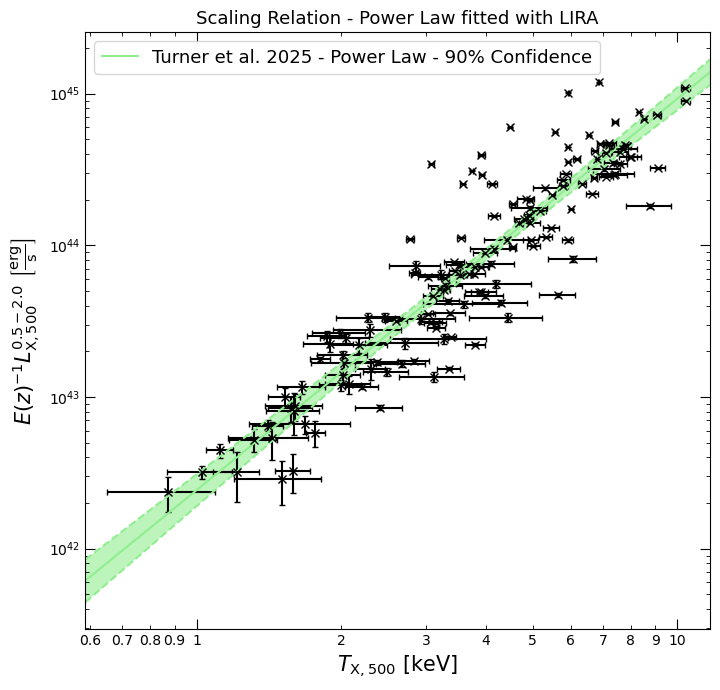

In [20]:
lx52_500_tx500.view(figsize=(7.3, 7),
                    save_path="../../outputs/figures/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lx52_500_tx500.pdf")

### $L^{0.5-2.0}_{\rm{X,500ce}}$-$T_{\rm{X,500ce}}$

In [22]:
# Setting up property variables in astropy quantity objects
lx500ce_52 = (Quantity(sdssxcs_samp[['Lx52_500ce', 'Lx52_500ce-','Lx52_500ce+']].values, 'erg/s')*
              (sdssxcs_samp['E'].values[..., None]**-1))
tx500ce = Quantity(sdssxcs_samp[['Tx_500ce', 'Tx_500ce-', 'Tx_500ce+']].values, 'keV')

lx52_500ce_tx500ce = scaling_relation_lira(lx500ce_52[:, 0], lx500ce_52[:, 1:], tx500ce[:, 0], tx500ce[:, 1:], lx_norm, tx_norm, 
                                           y_name=r"$E(z)^{-1}L^{0.5-2.0}_{\rm{X,500ce}}$", x_name=r"$T_{\rm{X,500ce}}$", 
                                           dim_hubb_ind=-1, point_names=sdssxcs_samp['name'].values)
lx52_500ce_tx500ce.model_colour = 'tan'
lx52_500ce_tx500ce.author = 'Turner et al.'
lx52_500ce_tx500ce.year = 2025
lx52_500ce_tx500ce.name = r'Turner et al. $E(z)^{-1}L^{0.5-2.0}_{\rm{X,500ce}}$-$T_{\rm{X,500ce}}$'
lx52_500ce_tx500ce.save("../../outputs/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lx52_500ce_tx500ce.xgarel")

/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:414: UserWarning: 2 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:450: UserWarning: 2 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


In [23]:
print("Slope of {v:.3f} ± {e:.3f}\n".format(v=lx52_500ce_tx500ce.pars[0][0], e=lx52_500ce_tx500ce.pars[0][1]))
print("Normalisation of {v:.3f} ± {e:.3f}\n".format(v=lx52_500ce_tx500ce.pars[1][0], e=lx52_500ce_tx500ce.pars[1][1]))
print("Scatter of {v:.3f} ± {e:.3f}".format(v=lx52_500ce_tx500ce.scatter_par[0], e=lx52_500ce_tx500ce.scatter_par[1]))

Slope of 2.450 ± 0.086

Normalisation of 0.641 ± 0.027

Scatter of 0.203 ± 0.015


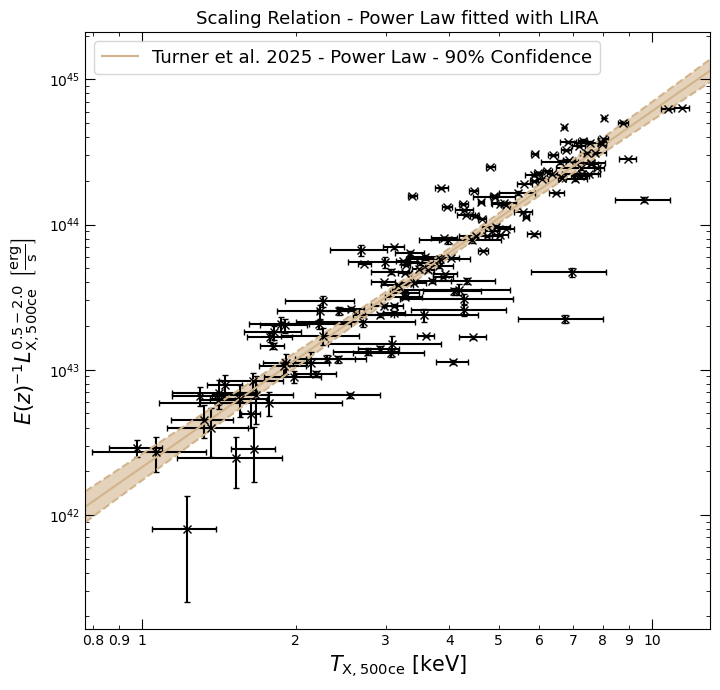

In [24]:
lx52_500ce_tx500ce.view(figsize=(7.3, 7),
                        save_path="../../outputs/figures/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lx52_500ce_tx500ce.pdf")

### $L^{\rm{bol}}_{\rm{X,500}}$-$T_{X, 500}$

In [25]:
# Setting up property variables in astropy quantity objects
lx500_bol = (Quantity(sdssxcs_samp[['Lxbol_500', 'Lxbol_500-','Lxbol_500+']].values, 'erg/s')*
              (sdssxcs_samp['E'].values[..., None]**-1))
tx500 = Quantity(sdssxcs_samp[['Tx_500', 'Tx_500-', 'Tx_500+']].values, 'keV')

lxbol_500_tx500 = scaling_relation_lira(lx500_bol[:, 0], lx500_bol[:, 1:], tx500[:, 0], tx500[:, 1:], lx_norm, tx_norm, 
                                        y_name=r"$E(z)^{-1}L^{\rm{bol}}_{\rm{X,500}}$", x_name=r"$T_{\rm{X,500}}$", 
                                        dim_hubb_ind=-1, point_names=sdssxcs_samp['name'].values)
lxbol_500_tx500.model_colour = 'darkslategray'
lxbol_500_tx500.author = 'Turner et al.'
lxbol_500_tx500.year = 2025
lxbol_500_tx500.name = r'Turner et al. $E(z)^{-1}L^{\rm{bol}}_{\rm{X,500}}$-$T_{\rm{X,500}}$'
lxbol_500_tx500.save("../../outputs/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lxbol_500_tx500.xgarel")

/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:414: UserWarning: 1 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:450: UserWarning: 1 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


In [26]:
print("Slope of {v:.3f} ± {e:.3f}\n".format(v=lxbol_500_tx500.pars[0][0], e=lxbol_500_tx500.pars[0][1]))
print("Normalisation of {v:.3f} ± {e:.3f}\n".format(v=lxbol_500_tx500.pars[1][0], e=lxbol_500_tx500.pars[1][1]))
print("Scatter of {v:.3f} ± {e:.3f}".format(v=lxbol_500_tx500.scatter_par[0], e=lxbol_500_tx500.scatter_par[1]))

Slope of 3.016 ± 0.101

Normalisation of 2.620 ± 0.133

Scatter of 0.248 ± 0.016


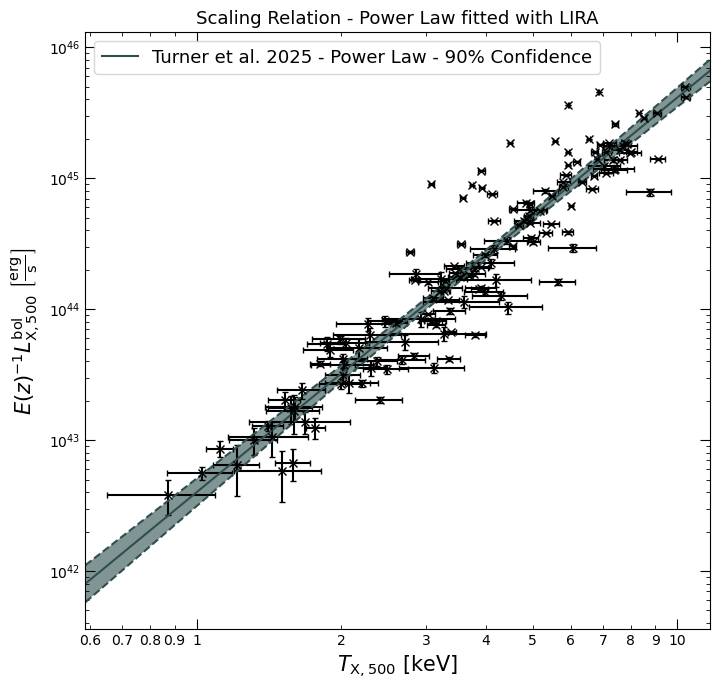

In [27]:
lxbol_500_tx500.view(figsize=(7.3, 7),
                     save_path="../../outputs/figures/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lxbol_500_tx500.pdf")

### $L^{\rm{bol}}_{\rm{X,500ce}}$-$T_{X, 500ce}$

In [28]:
# Setting up property variables in astropy quantity objects
lx500ce_bol = (Quantity(sdssxcs_samp[['Lxbol_500ce', 'Lxbol_500ce-','Lxbol_500ce+']].values, 'erg/s')*
                  (sdssxcs_samp['E'].values[..., None]**-1))
tx500ce = Quantity(sdssxcs_samp[['Tx_500ce', 'Tx_500ce-', 'Tx_500ce+']].values, 'keV')

lxbol_500ce_tx500ce = scaling_relation_lira(lx500ce_bol[:, 0], lx500ce_bol[:, 1:], tx500ce[:, 0], tx500ce[:, 1:], lx_norm, tx_norm, 
                                            y_name=r"$E(z)^{-1}L^{\rm{bol}}_{\rm{X,500ce}}$", x_name=r"$T_{\rm{X,500ce}}$", 
                                            dim_hubb_ind=-1, point_names=sdssxcs_samp['name'].values)
lxbol_500ce_tx500ce.model_colour = 'purple'
lxbol_500ce_tx500ce.author = 'Turner et al.'
lxbol_500ce_tx500ce.year = 2025
lxbol_500ce_tx500ce.name = r'Turner et al. $E(z)^{-1}L^{\rm{bol}}_{\rm{X,500ce}}$-$T_{\rm{X,500ce}}$'
lxbol_500ce_tx500ce.save("../../outputs/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lxbol_500ce_tx500ce.xgarel")

/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:414: UserWarning: 1 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:450: UserWarning: 1 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


In [29]:
print("Slope of {v:.3f} ± {e:.3f}\n".format(v=lxbol_500ce_tx500ce.pars[0][0], e=lxbol_500ce_tx500ce.pars[0][1]))
print("Normalisation of {v:.3f} ± {e:.3f}\n".format(v=lxbol_500ce_tx500ce.pars[1][0], e=lxbol_500ce_tx500ce.pars[1][1]))
print("Scatter of {v:.3f} ± {e:.3f}".format(v=lxbol_500ce_tx500ce.scatter_par[0], e=lxbol_500ce_tx500ce.scatter_par[1]))

Slope of 2.881 ± 0.084

Normalisation of 1.939 ± 0.081

Scatter of 0.194 ± 0.015


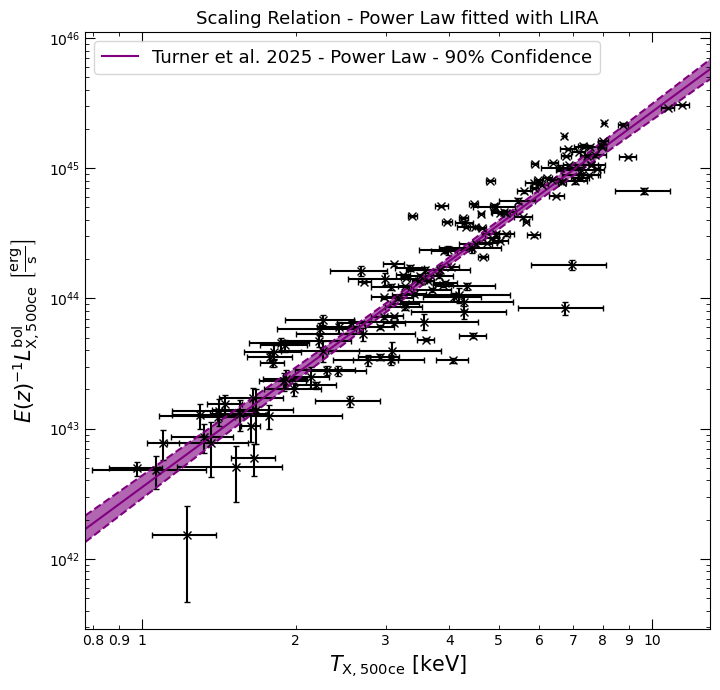

In [30]:
lxbol_500ce_tx500ce.view(figsize=(7.3, 7),
                         save_path="../../outputs/figures/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lxbol_500ce_tx500ce.pdf")

### $L^{0.5-2.0}_{\rm{X,2500}}$-$T_{X, 2500}$

In [31]:
# Setting up property variables in astropy quantity objects
lx2500_52 = Quantity(sdssxcs_samp[['Lx52_2500', 'Lx52_2500-','Lx52_2500+']].values, 'erg/s')*(sdssxcs_samp['E'].values[..., None]**-1)
tx2500 = Quantity(sdssxcs_samp[['Tx_2500', 'Tx_2500-', 'Tx_2500+']].values, 'keV')

lx52_2500_tx2500 = scaling_relation_lira(lx2500_52[:, 0], lx2500_52[:, 1:], tx2500[:, 0], tx2500[:, 1:], lx_norm, tx_norm, 
                                         y_name=r"$E(z)^{-1}L^{0.5-2.0}_{\rm{X,2500}}$", x_name=r"$T_{\rm{X,2500}}$", 
                                         dim_hubb_ind=-1, point_names=sdssxcs_samp['name'].values)
lx52_2500_tx2500.model_colour = 'sienna'
lx52_2500_tx2500.author = 'Turner et al.'
lx52_2500_tx2500.year = 2025
lx52_2500_tx2500.name = r'Turner et al. $E(z)^{-1}L^{0.5-2.0}_{\rm{X,2500}}$-$T_{\rm{X,2500}}$'
lx52_2500_tx2500.save("../../outputs/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lx52_2500_tx2500.xgarel")

/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:414: UserWarning: 17 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:450: UserWarning: 17 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


In [32]:
print("Slope of {v:.3f} ± {e:.3f}\n".format(v=lx52_2500_tx2500.pars[0][0], e=lx52_2500_tx2500.pars[0][1]))
print("Normalisation of {v:.3f} ± {e:.3f}\n".format(v=lx52_2500_tx2500.pars[1][0], e=lx52_2500_tx2500.pars[1][1]))
print("Scatter of {v:.3f} ± {e:.3f}".format(v=lx52_2500_tx2500.scatter_par[0], e=lx52_2500_tx2500.scatter_par[1]))

Slope of 2.801 ± 0.122

Normalisation of 0.527 ± 0.031

Scatter of 0.281 ± 0.019


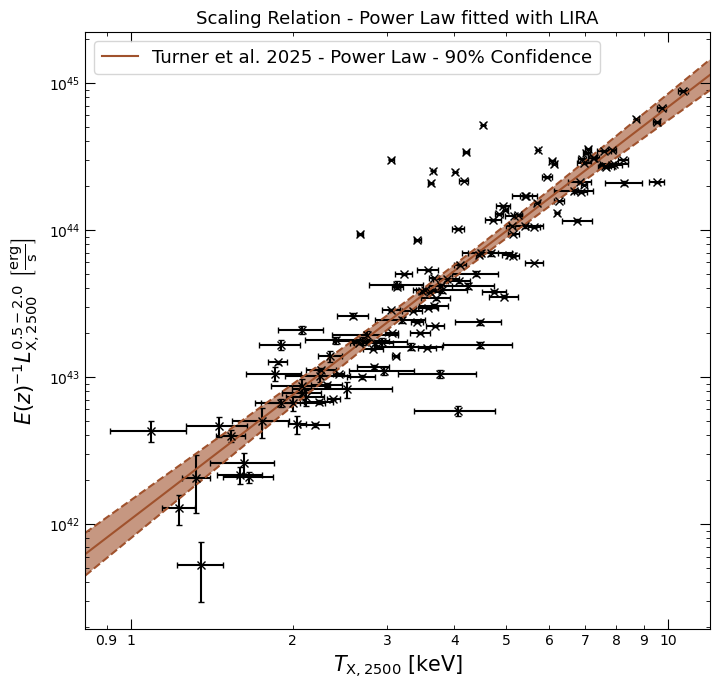

In [33]:
lx52_2500_tx2500.view(figsize=(7.3, 7),
                      save_path="../../outputs/figures/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lx52_2500_tx2500.pdf")

### $L^{\rm{bol}}_{\rm{X,500}}$-$T_{X, 500}$

In [34]:
# Setting up property variables in astropy quantity objects
lx2500_bol = (Quantity(sdssxcs_samp[['Lxbol_2500', 'Lxbol_2500-','Lxbol_2500+']].values, 'erg/s')*
                  (sdssxcs_samp['E'].values[..., None]**-1))
tx2500 = Quantity(sdssxcs_samp[['Tx_2500', 'Tx_2500-', 'Tx_2500+']].values, 'keV')

lxbol_2500_tx2500 = scaling_relation_lira(lx2500_bol[:, 0], lx2500_bol[:, 1:], tx2500[:, 0], tx2500[:, 1:], lx_norm, tx_norm, 
                                          y_name=r"$E(z)^{-1}L^{\rm{bol}}_{\rm{X,2500}}$", x_name=r"$T_{\rm{X,2500}}$", 
                                          dim_hubb_ind=-1, point_names=sdssxcs_samp['name'].values)
lxbol_2500_tx2500.model_colour = 'lightseagreen'
lxbol_2500_tx2500.author = 'Turner et al.'
lxbol_2500_tx2500.year = 2025
lxbol_2500_tx2500.name = r'Turner et al. $E(z)^{-1}L^{\rm{bol}}_{\rm{X,2500}}$-$T_{\rm{X,2500}}$'
lxbol_2500_tx2500.save("../../outputs/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lxbol_2500_tx2500.xgarel")

/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:414: UserWarning: 17 sources have NaN values or negative uncertainties and have been excluded
  third_dim_info = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm, True, point_names,


  |**************************************************| 100%


/Users/dt237/code/main_branch_xga/XGA/xga/relations/fit.py:450: UserWarning: 17 sources have NaN values or negative uncertainties and have been excluded
  throw_away, sec_throw_away = _fit_initialise(y_values, y_errs, x_values, x_errs, y_norm, x_norm)


In [35]:
print("Slope of {v:.3f} ± {e:.3f}\n".format(v=lxbol_2500_tx2500.pars[0][0], e=lxbol_2500_tx2500.pars[0][1]))
print("Normalisation of {v:.3f} ± {e:.3f}\n".format(v=lxbol_2500_tx2500.pars[1][0], e=lxbol_2500_tx2500.pars[1][1]))
print("Scatter of {v:.3f} ± {e:.3f}".format(v=lxbol_2500_tx2500.scatter_par[0], e=lxbol_2500_tx2500.scatter_par[1]))

Slope of 3.242 ± 0.121

Normalisation of 1.580 ± 0.093

Scatter of 0.278 ± 0.019


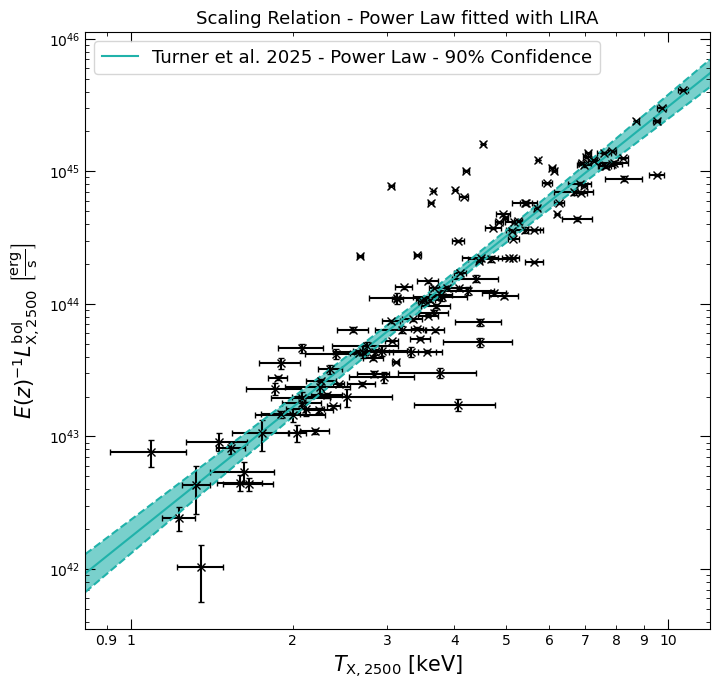

In [36]:
lxbol_2500_tx2500.view(figsize=(7.3, 7),
                       save_path="../../outputs/figures/scaling_relations/sdssrm-xcs_new/lx-tx/turner2025_lxbol_2500_tx2500.pdf")